# OpenCV Image Processing

**Thu Kha Pyeit Sone Kyaw (Baron)** · [GitHub](https://github.com/baronkyaw)

A reproducible Python project using the church image from image-processing coursework.
This is a new notebook rebuilt with AI assistance; it is not a recovered copy of the earlier coursework notebook.

The pipeline loads an image, resizes it, converts it to grayscale, adjusts brightness
and contrast, crops a region of interest, adds a rectangle and text, and saves the results.

**Run:** keep this notebook beside `church.png`, then use **Restart Kernel and Run All** in Jupyter.
Install the packages in `requirements.txt` first if needed. All paths are relative to this folder.


## 1. Imports and file paths

OpenCV handles image processing, NumPy supports array checks, and Matplotlib displays
the results inside the notebook. No desktop image window is required.


In [1]:
from io import BytesIO
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

INPUT_PATH = Path("church.png")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)


OpenCV: 5.0.0
NumPy: 2.3.5


## 2. Load and display the original

OpenCV reads color channels in **BGR** order. Matplotlib expects **RGB**, so color
images are converted before display. The input PNG is loaded as a three-channel
color image; any alpha channel is discarded by `IMREAD_COLOR`.


Original: 1536 × 1024 pixels; 3 channels; uint8


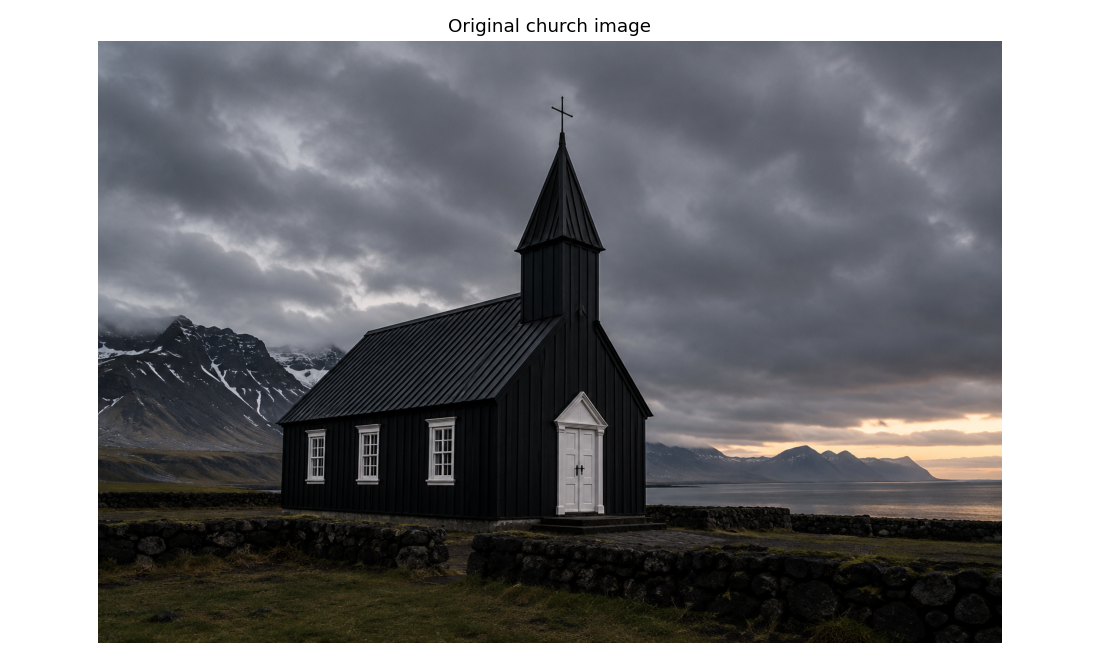

In [2]:
def display_image(ax, image, title):
    if image.ndim == 2:
        ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    else:
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")


if not INPUT_PATH.is_file():
    raise FileNotFoundError("Keep church.png in the same folder as this notebook.")

original = cv2.imread(str(INPUT_PATH), cv2.IMREAD_COLOR)
if original is None:
    raise ValueError("OpenCV could not decode church.png.")

height, width, channels = original.shape
print(f"Original: {width} × {height} pixels; {channels} channels; {original.dtype}")

fig, ax = plt.subplots(figsize=(10, 6))
display_image(ax, original, "Original church image")
plt.tight_layout()
plt.show()


## 3. Resize while keeping the aspect ratio

The target width is 1280 pixels. The height is calculated from the original proportions,
with rounding to a whole pixel. `INTER_AREA` is used for this reduction in size.


In [3]:
target_width = 1280
target_height = round(height * target_width / width)
resized = cv2.resize(
    original, (target_width, target_height), interpolation=cv2.INTER_AREA
)
print(f"Resized: {resized.shape[1]} × {resized.shape[0]} pixels")


Resized: 1280 × 853 pixels


## 4. Convert to grayscale

Grayscale stores one intensity value per pixel instead of three color channels.
The image width and height stay the same.


In [4]:
grayscale = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
print("Grayscale array shape (height, width):", grayscale.shape)


Grayscale array shape (height, width): (1024, 1536)


## 5. Adjust brightness and contrast

`alpha` multiplies pixel values and `beta` adds an offset. The selected positive
values make this dark image brighter. Values above 255 are clipped to 255 in the
8-bit result. `convertScaleAbs` also takes the absolute value; that does not change
the result here because pixel values, `alpha`, and `beta` are nonnegative.


In [5]:
alpha = 1.15
beta = 20
enhanced = cv2.convertScaleAbs(original, alpha=alpha, beta=beta)

original_intensity = grayscale.mean()
enhanced_intensity = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY).mean()
print(f"Mean grayscale intensity: {original_intensity:.2f} → {enhanced_intensity:.2f} / 255")


Mean grayscale intensity: 80.83 → 112.69 / 255


## 6. Crop a region of interest (ROI)

These coordinates were selected manually for the bundled church image. This is
a crop, not automatic object detection. In an image array, **rows (y) come before
columns (x)**. The end coordinates in a slice are excluded.


In [6]:
x1, y1 = 280, 80
x2, y2 = 1000, 850

if not (0 <= x1 < x2 <= width and 0 <= y1 < y2 <= height):
    raise ValueError("ROI coordinates must be inside the image.")

cropped = original[y1:y2, x1:x2].copy()
print(f"Crop: {cropped.shape[1]} × {cropped.shape[0]} pixels")


Crop: 720 × 770 pixels


## 7. Add a rectangle and text

Drawing functions modify their input array. Copying the original keeps it unchanged.
The green rectangle marks the same ROI used for the crop. A dark text outline makes
the white label readable against the sky.


In [7]:
annotated = original.copy()
cv2.rectangle(annotated, (x1, y1), (x2 - 1, y2 - 1), (0, 200, 0), 4)

label = "Baron | OpenCV"
position = (30, 60)
cv2.putText(
    annotated, label, position, cv2.FONT_HERSHEY_SIMPLEX,
    1.3, (0, 0, 0), 7, cv2.LINE_AA
)
cv2.putText(
    annotated, label, position, cv2.FONT_HERSHEY_SIMPLEX,
    1.3, (255, 255, 255), 3, cv2.LINE_AA
)
print("Added the ROI rectangle and Baron | OpenCV label.")


Added the ROI rectangle and Baron | OpenCV label.


## 8. Save the results and compare them

Each processed image is saved as a PNG. `imwrite` is checked so a failed save is
reported. The comparison grid provides a quick visual check of the whole pipeline.


Saved: outputs/resized_church.png
Saved: outputs/grayscale_church.png
Saved: outputs/enhanced_church.png
Saved: outputs/cropped_church.png
Saved: outputs/annotated_church.png


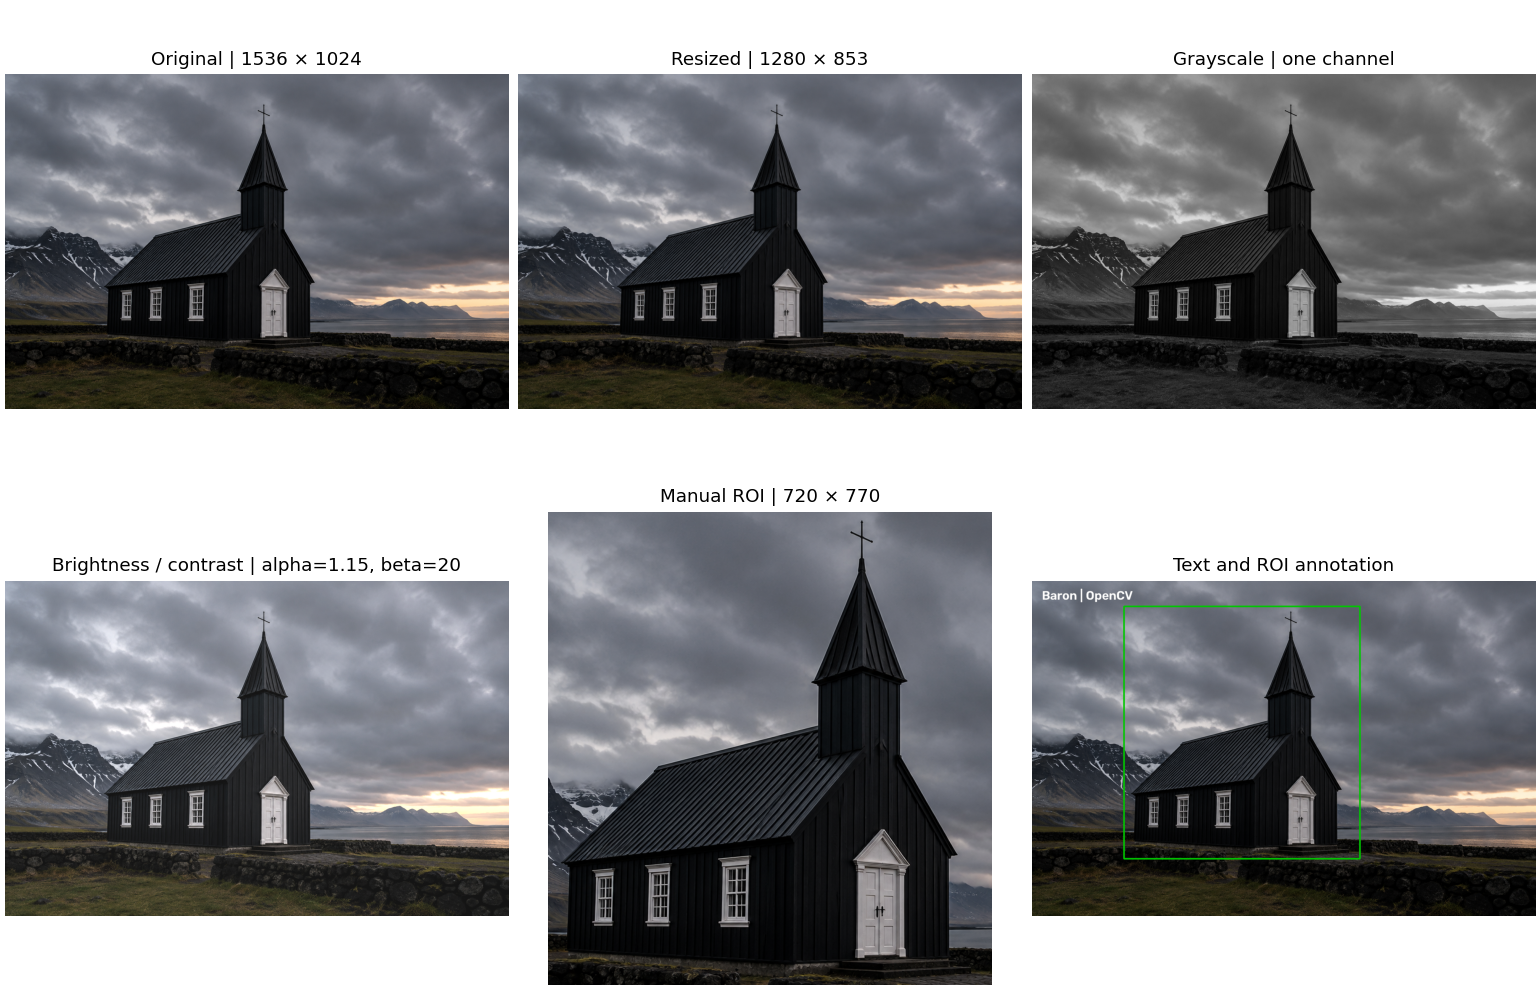

Saved: outputs/comparison.png


In [8]:
processed_images = {
    "resized_church.png": resized,
    "grayscale_church.png": grayscale,
    "enhanced_church.png": enhanced,
    "cropped_church.png": cropped,
    "annotated_church.png": annotated,
}

for filename, image in processed_images.items():
    path = OUTPUT_DIR / filename
    if not cv2.imwrite(str(path), image):
        raise OSError(f"Could not save {path}")
    print("Saved:", path)

panels = [
    (original, f"Original | {width} × {height}"),
    (resized, f"Resized | {target_width} × {target_height}"),
    (grayscale, "Grayscale | one channel"),
    (enhanced, f"Brightness / contrast | alpha={alpha}, beta={beta}"),
    (cropped, f"Manual ROI | {x2 - x1} × {y2 - y1}"),
    (annotated, "Text and ROI annotation"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)
for ax, (image, title) in zip(axes.flat, panels):
    display_image(ax, image, title)

# Render a complete PNG in memory, then write it to disk.
comparison_buffer = BytesIO()
fig.savefig(comparison_buffer, format="png", dpi=120)
(OUTPUT_DIR / "comparison.png").write_bytes(comparison_buffer.getvalue())
plt.show()
print("Saved:", OUTPUT_DIR / "comparison.png")


## 9. Check the outputs

These checks confirm dimensions, PNG round trips, changed annotation pixels and
preservation of the original image. They do not judge visual quality; inspect the
comparison grid for that.


In [9]:
assert resized.shape == (target_height, target_width, 3)
assert grayscale.shape == (height, width)
assert cropped.shape == (y2 - y1, x2 - x1, 3)
assert enhanced.dtype == np.uint8
assert np.any(annotated != original)
assert np.array_equal(original, cv2.imread(str(INPUT_PATH), cv2.IMREAD_COLOR))

for filename, expected in processed_images.items():
    saved = cv2.imread(str(OUTPUT_DIR / filename), cv2.IMREAD_UNCHANGED)
    assert saved is not None, f"Could not reload {filename}"
    assert np.array_equal(saved, expected), f"PNG round trip failed: {filename}"

assert cv2.imread(str(OUTPUT_DIR / "comparison.png")) is not None
print("All output checks passed.")
print("Original input preserved; five processed PNGs and a comparison grid saved.")


All output checks passed.
Original input preserved; five processed PNGs and a comparison grid saved.


## Result and next experiments

For the bundled 1536 × 1024 input, the resize produces a 1280 × 853 image and the
manually selected crop produces a 720 × 770 image. The notebook saves five processed
images plus a comparison grid. The earlier text/logo coursework image is included
separately as `final_church_image.png`; this pipeline does not regenerate that logo.

To practise adapting the code, change `alpha` and `beta`, select a different ROI,
or change the annotation text. Restart the kernel and run all cells after an edit.

References: [image operations](https://docs.opencv.org/4.x/d3/df2/tutorial_py_basic_ops.html)
and [drawing functions](https://docs.opencv.org/4.x/dc/da5/tutorial_py_drawing_functions.html).
